# Array Response Experiments

Interactive notebook for comparing chunk sizes and chunk-shape strategies on the Helios evaluation path.

The first benchmark cell sweeps chunk sizes across strategies. The second benchmark cell sweeps `reduction_tile_cap` across the same chunk sizes.

In [2]:
from __future__ import annotations

import os
import statistics
import sys
import time
from pathlib import Path

import torch

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
PROJECT_ROOT = PROJECT_ROOT.resolve()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.arraySimulation import useChunkShapeStrategy
from train.config import loadRunConfig, resolveDevice, resolveTarget, runConfigToDict
from train.evolve import EvolutionController
from train.objective import evaluateBatch

print(f'project_root: {PROJECT_ROOT}')
print(f'cwd: {Path.cwd()}')

try:
    import pandas as pd
except Exception:
    pd = None

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None


project_root: /home/aryan/projects/Helios
cwd: /home/aryan/projects/Helios


In [ ]:
# Experiment knobs
CONFIG_PATH = PROJECT_ROOT / Path('configs/evo.yaml')
SWEEP = 'both'  # 'linear', 'wide', or 'both'
CHUNK_SIZES = [400_000]
STRATEGIES = ['cap_reduction']
REDUCTION_TILE_CAP = 100_000
REDUCTION_TILE_CAPS = [50_000, 60_000, 70_000 ]
CAP_SWEEP_STRATEGIES = ['cap_reduction']
RUNS = 10
WARMUP = 1
ALLOW_SHARED_TARGET_FAST_PATH = True
DTYPE_OVERRIDE = None  # e.g. torch.float16 or torch.float32


In [4]:
def _mean(values: list[float]) -> float:
    return statistics.mean(values) if values else 0.0


def _stdev(values: list[float]) -> float:
    return statistics.pstdev(values) if len(values) > 1 else 0.0


def _sync(device: torch.device) -> None:
    if device.type == 'cuda':
        torch.cuda.synchronize(device)


def _candidate_chunk_sizes(chunk_size: int, sweep_mode: str, evolution_config):
    if sweep_mode == 'linear':
        return chunk_size, evolution_config.wideResponseChunkSize
    if sweep_mode == 'wide':
        return evolution_config.linearResponseChunkSize, chunk_size
    return chunk_size, chunk_size


def build_controller_and_batch(config_path: Path, dtype_override=None):
    config_path = Path(config_path).resolve()
    run_config = loadRunConfig(config_path)
    target = resolveTarget(run_config)
    device, dtype = resolveDevice(run_config)
    if dtype_override is not None:
        dtype = dtype_override

    controller = EvolutionController(
        config=run_config.evolution,
        targetSpec=target,
        arraySpec=run_config.array,
        lossParams=run_config.loss,
        experimentName=run_config.experiment.name,
        archiveRoot=run_config.experiment.archiveDir,
        loggingConfig=run_config.logging,
        checkpointConfig=run_config.checkpoint,
        workerConfig=run_config.workers,
        targetMode=run_config.experiment.targetMode,
        sourceConfigPath=run_config.sourcePath,
        resolvedConfig=runConfigToDict(run_config),
        writerLogDir=run_config.experiment.logDir,
    )

    with torch.no_grad():
        batch = controller.initEvolution(dtype=dtype, device=device)
        loss_params = controller._lossParamsForStep(0)

    return run_config, controller, batch, loss_params, device, dtype


def benchmark_chunk_shapes(
    *,
    controller,
    batch,
    loss_params,
    sweep: str,
    chunk_sizes: list[int],
    strategies: list[str],
    reduction_tile_cap: int,
    runs: int,
    warmup: int,
    allow_shared_target_fast_path: bool,
):
    rows = []
    with torch.no_grad():
        for strategy in strategies:
            with useChunkShapeStrategy(strategy, reductionTileCap=reduction_tile_cap):
                for chunk_size in chunk_sizes:
                    linear_chunk_size, wide_chunk_size = _candidate_chunk_sizes(
                        chunk_size,
                        sweep,
                        controller.config,
                    )
                    timings_ms = []
                    gpu_peaks_mb = []
                    score_means = []
                    resolved_linear_chunk_size = None
                    resolved_wide_chunk_size = None

                    for iteration in range(warmup + runs):
                        _sync(batch.device)
                        start = time.perf_counter()
                        evaluation = evaluateBatch(
                            batch=batch,
                            target=controller.targetSpec,
                            params=loss_params,
                            targetMode=controller.targetMode,
                            linearResponseChunkSize=linear_chunk_size,
                            wideResponseChunkSize=wide_chunk_size,
                            allowSharedTargetFastPath=allow_shared_target_fast_path,
                        )
                        _sync(batch.device)
                        elapsed_ms = (time.perf_counter() - start) * 1000.0

                        if iteration >= warmup:
                            timings_ms.append(elapsed_ms)
                            score_means.append(float(evaluation.totalLoss.mean().item()))
                            if evaluation.diagnostics.gpuMaxMemoryMB is not None:
                                gpu_peaks_mb.append(float(evaluation.diagnostics.gpuMaxMemoryMB))

                        resolved_linear_chunk_size = evaluation.diagnostics.linearResponseChunkSize
                        resolved_wide_chunk_size = evaluation.diagnostics.wideResponseChunkSize

                    rows.append(
                        {
                            'strategy': strategy,
                            'requested_chunk_size': chunk_size,
                            'resolved_linear_chunk_size': resolved_linear_chunk_size,
                            'resolved_wide_chunk_size': resolved_wide_chunk_size,
                            'mean_total_ms': _mean(timings_ms),
                            'std_total_ms': _stdev(timings_ms),
                            'min_total_ms': min(timings_ms) if timings_ms else 0.0,
                            'max_total_ms': max(timings_ms) if timings_ms else 0.0,
                            'mean_gpu_mb': _mean(gpu_peaks_mb),
                            'mean_score': _mean(score_means),
                            'timings_ms': timings_ms,
                        }
                    )

    rows.sort(key=lambda row: (row['requested_chunk_size'], row['mean_total_ms']))
    return rows


def benchmark_reduction_tile_caps(
    *,
    controller,
    batch,
    loss_params,
    sweep: str,
    chunk_sizes: list[int],
    strategies: list[str],
    reduction_tile_caps: list[int],
    runs: int,
    warmup: int,
    allow_shared_target_fast_path: bool,
):
    rows = []
    with torch.no_grad():
        for reduction_tile_cap in reduction_tile_caps:
            for strategy in strategies:
                with useChunkShapeStrategy(strategy, reductionTileCap=reduction_tile_cap):
                    for chunk_size in chunk_sizes:
                        linear_chunk_size, wide_chunk_size = _candidate_chunk_sizes(
                            chunk_size,
                            sweep,
                            controller.config,
                        )
                        timings_ms = []
                        gpu_peaks_mb = []
                        score_means = []

                        for iteration in range(warmup + runs):
                            _sync(batch.device)
                            start = time.perf_counter()
                            evaluation = evaluateBatch(
                                batch=batch,
                                target=controller.targetSpec,
                                params=loss_params,
                                targetMode=controller.targetMode,
                                linearResponseChunkSize=linear_chunk_size,
                                wideResponseChunkSize=wide_chunk_size,
                                allowSharedTargetFastPath=allow_shared_target_fast_path,
                            )
                            _sync(batch.device)
                            elapsed_ms = (time.perf_counter() - start) * 1000.0

                            if iteration >= warmup:
                                timings_ms.append(elapsed_ms)
                                score_means.append(float(evaluation.totalLoss.mean().item()))
                                if evaluation.diagnostics.gpuMaxMemoryMB is not None:
                                    gpu_peaks_mb.append(float(evaluation.diagnostics.gpuMaxMemoryMB))

                        rows.append(
                            {
                                'strategy': strategy,
                                'reduction_tile_cap': reduction_tile_cap,
                                'requested_chunk_size': chunk_size,
                                'mean_total_ms': _mean(timings_ms),
                                'std_total_ms': _stdev(timings_ms),
                                'mean_gpu_mb': _mean(gpu_peaks_mb),
                                'mean_score': _mean(score_means),
                                'timings_ms': timings_ms,
                            }
                        )

    rows.sort(
        key=lambda row: (
            row['requested_chunk_size'],
            row['strategy'],
            row['reduction_tile_cap'],
        )
    )
    return rows


def display_rows(rows):
    if pd is not None:
        frame = pd.DataFrame(rows)
        display(frame)
        return frame
    for row in rows:
        print(row)
    return rows


In [6]:
run_config, controller, batch, loss_params, device, dtype = build_controller_and_batch(
    CONFIG_PATH,
    dtype_override=DTYPE_OVERRIDE,
)

print(f'config: {CONFIG_PATH}')
print(f'device: {device} dtype={dtype}')
print(f'batch_size: {batch.batchSize} elements: {batch.N}')

rows = benchmark_chunk_shapes(
    controller=controller,
    batch=batch,
    loss_params=loss_params,
    sweep=SWEEP,
    chunk_sizes=CHUNK_SIZES,
    strategies=STRATEGIES,
    reduction_tile_cap=REDUCTION_TILE_CAP,
    runs=RUNS,
    warmup=WARMUP,
    allow_shared_target_fast_path=ALLOW_SHARED_TARGET_FAST_PATH,
)

results = display_rows(rows)


config: /home/aryan/projects/Helios/configs/evo.yaml
device: cuda dtype=torch.float32
batch_size: 50 elements: 25281
{'strategy': 'balanced', 'requested_chunk_size': 400000, 'resolved_linear_chunk_size': None, 'resolved_wide_chunk_size': None, 'mean_total_ms': 0.0, 'std_total_ms': 0.0, 'min_total_ms': 0.0, 'max_total_ms': 0.0, 'mean_gpu_mb': 0.0, 'mean_score': 0.0, 'timings_ms': []}
{'strategy': 'cap_reduction', 'requested_chunk_size': 400000, 'resolved_linear_chunk_size': None, 'resolved_wide_chunk_size': None, 'mean_total_ms': 0.0, 'std_total_ms': 0.0, 'min_total_ms': 0.0, 'max_total_ms': 0.0, 'mean_gpu_mb': 0.0, 'mean_score': 0.0, 'timings_ms': []}
{'strategy': 'grid_first', 'requested_chunk_size': 400000, 'resolved_linear_chunk_size': None, 'resolved_wide_chunk_size': None, 'mean_total_ms': 0.0, 'std_total_ms': 0.0, 'min_total_ms': 0.0, 'max_total_ms': 0.0, 'mean_gpu_mb': 0.0, 'mean_score': 0.0, 'timings_ms': []}


In [20]:
# Reduction-tile-cap sweep across the same chunk sizes
cap_rows = benchmark_reduction_tile_caps(
    controller=controller,
    batch=batch,
    loss_params=loss_params,
    sweep=SWEEP,
    chunk_sizes=CHUNK_SIZES,
    strategies=CAP_SWEEP_STRATEGIES,
    reduction_tile_caps=REDUCTION_TILE_CAPS,
    runs=RUNS,
    warmup=WARMUP,
    allow_shared_target_fast_path=ALLOW_SHARED_TARGET_FAST_PATH,
)

cap_results = display_rows(cap_rows)


{'strategy': 'cap_reduction', 'reduction_tile_cap': 50000, 'requested_chunk_size': 400000, 'mean_total_ms': 8150.09134960128, 'std_total_ms': 18.26216348308594, 'mean_gpu_mb': 79.24267578125, 'mean_score': 0.5384077429771423, 'timings_ms': [8122.737801997573, 8175.171681010397, 8141.873234999366, 8164.494582000771, 8146.179447998293]}
{'strategy': 'cap_reduction', 'reduction_tile_cap': 60000, 'requested_chunk_size': 400000, 'mean_total_ms': 8153.9012691995595, 'std_total_ms': 18.45336127561933, 'mean_gpu_mb': 79.24267578125, 'mean_score': 0.5384077429771423, 'timings_ms': [8135.8978700009175, 8181.064878997859, 8130.64466099604, 8161.410225002328, 8160.488711000653]}
{'strategy': 'cap_reduction', 'reduction_tile_cap': 70000, 'requested_chunk_size': 400000, 'mean_total_ms': 8151.914203402703, 'std_total_ms': 16.956783036929046, 'mean_gpu_mb': 79.24267578125, 'mean_score': 0.5384077429771423, 'timings_ms': [8134.452900005272, 8150.139217003016, 8150.26375099842, 8183.673798004747, 8141.0

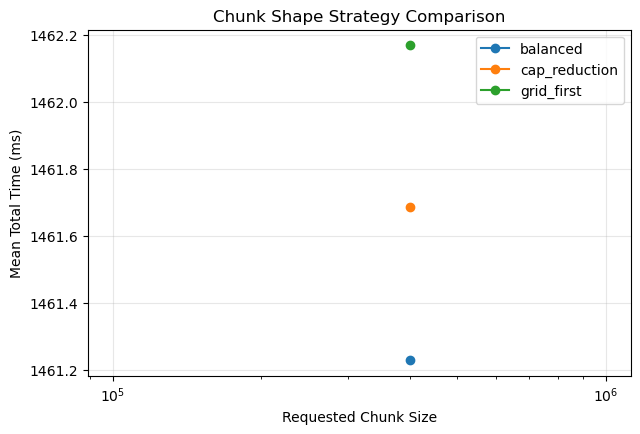

In [8]:
# Optional quick plot for the chunk-size sweep
if plt is None:
    print('matplotlib is not available in this environment')
else:
    grouped = {}
    for row in rows:
        grouped.setdefault(row['strategy'], []).append(row)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    for strategy, strategy_rows in grouped.items():
        strategy_rows = sorted(strategy_rows, key=lambda row: row['requested_chunk_size'])
        ax.plot(
            [row['requested_chunk_size'] for row in strategy_rows],
            [row['mean_total_ms'] for row in strategy_rows],
            marker='o',
            label=strategy,
        )

    ax.set_xscale('log')
    ax.set_xlabel('Requested Chunk Size')
    ax.set_ylabel('Mean Total Time (ms)')
    ax.set_title('Chunk Shape Strategy Comparison')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


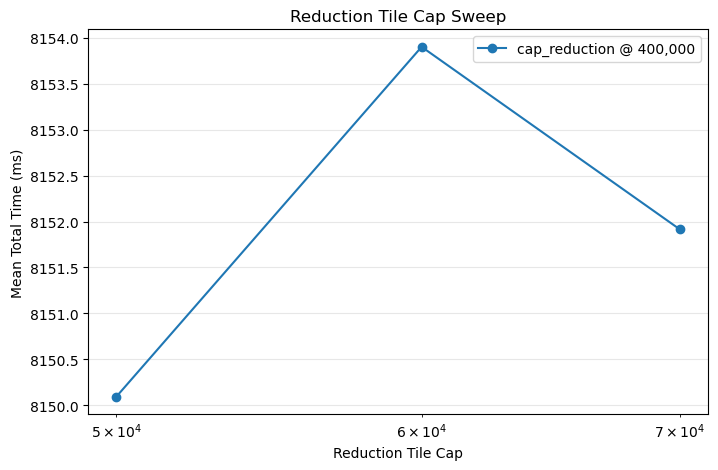

In [21]:
# Optional quick plot for the reduction-tile-cap sweep
if plt is None:
    print("matplotlib is not available in this environment")
else:
    grouped = {}
    for row in cap_rows:
        key = (row["strategy"], row["requested_chunk_size"])
        grouped.setdefault(key, []).append(row)

    fig, ax = plt.subplots(figsize=(8, 5))
    for (strategy, chunk_size), strategy_rows in sorted(grouped.items()):
        strategy_rows = sorted(strategy_rows, key=lambda row: row["reduction_tile_cap"])
        ax.plot(
            [row["reduction_tile_cap"] for row in strategy_rows],
            [row["mean_total_ms"] for row in strategy_rows],
            marker="o",
            label=f"{strategy} @ {chunk_size:,}",
        )

    ax.set_xscale("log")
    ax.set_xlabel("Reduction Tile Cap")
    ax.set_ylabel("Mean Total Time (ms)")
    ax.set_title("Reduction Tile Cap Sweep")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()
